# Análisis del Dataset Abalone y PCA
Este cuaderno analiza el dataset Abalone y aplica Análisis de Componentes Principales (PCA) para entender su estructura.

## 1. Carga del dataset

In [1]:
import pandas as pd

df = pd.read_csv('abalone.csv')
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## Descripción del dataset


El dataset Abalone se usa para la biología marina:

El objetivo es predecir la edad de Abalónes tasmanianos

Sexo se refiere a si es macho (M), hembra (F), o infantil (I).

Según Kaggle, todos los valores númericos fueron divididos entre 200 para optimizar su uso en redes neuronales

Length es la longitud máxima del caparazón en milímetros

Diameter es el diametro del caparazón, perpendicular a la longitud.

Height es la altura del Abulón, con este dentro de su caparazón.

Whole Weight es el peso total con caparazón.

Shucked Weight es el peso del Abulón sin el caparazón.

Viscera Weight es el peso de los intestinos después de desangrar al Abulón.

Shell Weight es el peso del caparazón después de secarlo.

Rings es la cantidad de anillos en el caparazón, con la edad siendo estimada como Rings + 1.5.



## Limpieza de datos

Se asegura que no existen valores nulos dentro del dataframe: Hay cero en total, así que no necesitamos deshacernos de cualquier entrada.

In [2]:

df.isnull().sum()


,0
Sex,0
Length,0
Diameter,0
Height,0
Whole weight,0
Shucked weight,0
Viscera weight,0
Shell weight,0
Rings,0


Nos deshacemos del sexo del abulón, ya que es un valor no numérico, y no es relevante para estimar la edad de este, y se guarda en un nuevo dataframe: df2.

In [5]:
df2 = df.drop(columns=['Sex'])

## Análisis exploratorio

Hacemos el describe del dataframe, que muestra varias métricas sobre todas las variables que usaremos: El promedio, desviación estándar, valores minimos, máximos y los quartiles.

In [4]:
df2.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


Se muestra una matriz de correlación para el dataframe. Se observa que hay una cantidad alta de correlación entre la mayoría de las variables, ya que cuatro de estas son pesos, y por la forma de los caparazones entre que la longitud crece el diametro también y vice versa.

Además se puede ver que Rings tiene una correlación positiva con todas las demás variables, aunque los niveles de correlación no son tan altos que como con las otras variables entre si mismas.

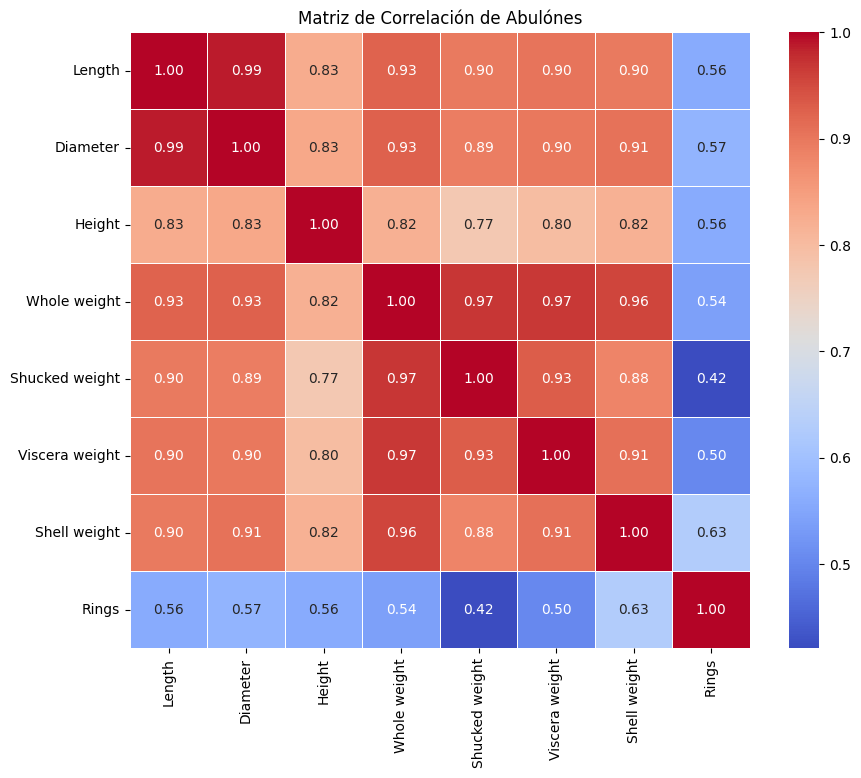

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
df2.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df2.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Abulónes')
plt.show()

## 2. Estandarización de datos

Estandarizamos a los valores de todos los datos, para prevenir que las variables con magnitudes más grandes tengan un efecto desproporcionadamente mayor en el PCA que las variables con menores magnitudes.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
std = scaler.fit_transform(df2)
pd.DataFrame(std,columns=df2.columns).head(10)

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,-0.574558,-0.432149,-1.064424,-0.641898,-0.607685,-0.726212,-0.638217,1.571544
1,-1.448986,-1.439929,-1.183978,-1.230277,-1.170910,-1.205221,-1.212987,-0.910013
2,0.050033,0.122130,-0.107991,-0.309469,-0.463500,-0.356690,-0.207139,-0.289624
3,-0.699476,-0.432149,-0.347099,-0.637819,-0.648238,-0.607600,-0.602294,0.020571
4,-1.615544,-1.540707,-1.423087,-1.272086,-1.215968,-1.287337,-1.320757,-0.910013
5,-0.824395,-1.087206,-1.064424,-0.973307,-0.983919,-0.940625,-0.853756,-0.599818
6,0.050033,0.071741,0.250672,-0.104505,-0.551363,-0.356690,0.655017,3.122516
7,0.174951,0.172519,-0.347099,-0.123880,-0.294533,-0.283698,0.152092,1.881738
8,-0.408000,-0.381760,-0.347099,-0.651076,-0.643732,-0.621286,-0.530447,-0.289624
9,0.216591,0.323686,0.250672,0.134109,-0.202164,-0.270012,0.583170,2.812322


## Matriz de covarianza

La diagonal es 1, ya que se creó la matríz de covarianza sobre un dataframe estandarizado. Además, es identica a la matriz de correlación creada sobre el dataframe no estandarizado.

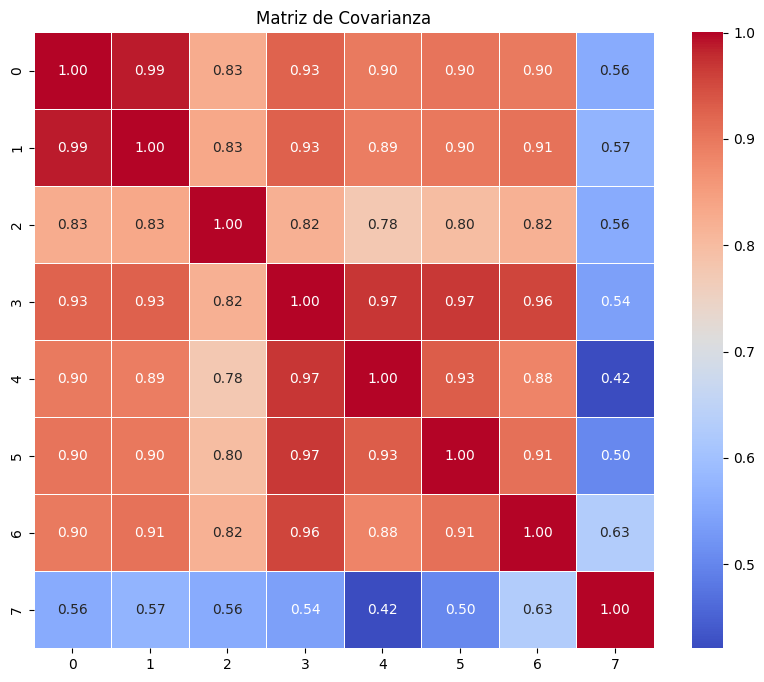

In [28]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cov_matrix = np.cov(std.T)

plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Covarianza')
plt.show()

## Eigenvalores y eigenvectores

Los eigenvalores indican la cantidad de varianza que le pertenece a cada componente principal, mientras que los eigenvectores representan la dirección de sus eigenvalores respectivos.

En este caso, se puede observar que el primer componente principal explica la mayor parte de la covarianza, los primeros dos representan ~90% y los primeros tres representan ~93% de esta.

In [21]:
import numpy as np

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalores:\n", eigenvalues)
total_eigenvalues = sum(eigenvalues)
print("\nVarianza explicada por cada eigenvalor (%):")
for i, eigen_val in enumerate(eigenvalues):
    print(f"Eigenvalor {i+1}: {eigen_val/total_eigenvalues * 100:.2f}%")

print("\nEigenvectores:\n", eigenvectors)

Eigenvalores:
 [6.71404654e+00 6.95779541e-01 2.58505008e-01 1.66029591e-01
 1.26972036e-02 6.39985662e-03 6.34879663e-02 8.49700060e-02]

Varianza explicada por cada eigenvalor (%):
Eigenvalor 1: 83.91%
Eigenvalor 2: 8.70%
Eigenvalor 3: 3.23%
Eigenvalor 4: 2.07%
Eigenvalor 5: 0.16%
Eigenvalor 6: 0.08%
Eigenvalor 7: 0.79%
Eigenvalor 8: 1.06%

Eigenvectores:
 [[ 3.72138505e-01  6.82826958e-02  3.10703159e-02 -6.04053517e-01
   6.98825733e-01 -1.63485531e-02 -4.74968278e-02  1.11248478e-02]
 [ 3.73094111e-01  4.00480412e-02  4.10050673e-02 -5.87594701e-01
  -7.12985166e-01  2.19254893e-04 -2.33754046e-02 -5.79110156e-02]
 [ 3.40026777e-01 -7.04631477e-02  8.99705624e-01  2.56777039e-01
   8.61445194e-03 -2.68817140e-03  2.66914622e-02  5.67292650e-02]
 [ 3.78307478e-01  1.37346192e-01 -2.06193609e-01  2.41848954e-01
  -8.33128844e-03 -8.50264371e-01  1.17255046e-01 -1.56556128e-02]
 [ 3.62454487e-01  2.98839921e-01 -2.08286301e-01  1.83245659e-01
  -9.28176619e-03  3.91100542e-01  6.2489

## Matriz de transformación:

Esta tiene el propósito de hacer visible que representa cada componente principal: Por ejemplo, ya que en el primer componente principal se tienen valores medianos y muy parecidos, es probable que este represente un valor general del tamaño del abulón.

En el segundo componente principal, se tiene una correlación negativa muy alta con el valor de rings, lo que significa que este representa a la edad de los abulónes

Finalmente, ya que solamente tiene una correlación alta con la altura del abulón, este componente principal deberia de representar a la altura de los abulónes.

In [49]:
import pandas as pd

idx = eigenvalues.argsort()[::-1]
sorted_eigenvalues = eigenvalues[idx]
sorted_eigenvectors = eigenvectors[:,idx]

transformation_matrix = sorted_eigenvectors

pc_columns = [f'PC{i+1}' for i in range(transformation_matrix.shape[1])]
transformation_df = pd.DataFrame(
    transformation_matrix,
    index=df2.columns,
    columns=pc_columns
)

print("Matriz de Transformación (más entendible):")
display(transformation_df)

Matriz de Transformación (más entendible):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Length,0.372139,0.068283,0.031070,-0.604054,0.011125,-0.047497,0.698826,-0.016349
Diameter,0.373094,0.040048,0.041005,-0.587595,-0.057911,-0.023375,-0.712985,0.000219
Height,0.340027,-0.070463,0.899706,0.256777,0.056729,0.026691,0.008614,-0.002688
Whole weight,0.378307,0.137346,-0.206194,0.241849,-0.015656,0.117255,-0.008331,-0.850264
Shucked weight,0.362454,0.298840,-0.208286,0.183246,0.398525,0.624893,-0.009282,0.391101
Viscera weight,0.368558,0.172979,-0.197380,0.265221,0.309821,-0.765844,-0.027346,0.204179
Shell weight,0.370758,-0.045400,-0.161574,0.244192,-0.830564,0.032832,0.047395,0.285624
Rings,0.242713,-0.921204,-0.192144,0.043310,0.220026,0.068196,0.008421,0.023370


## Varianza explicada:

Continuando de la parte de eigenvalores y eigenvectores, en esta sección se ahce una gráfica, en donde Y es el la varianza explicada acumulada (se va sumando), y X son los componentes principales (la cantidad de estos).

Se puede observar que con dos componenters principales se alcanza a >90%, y con tres se alcanza un >95%.

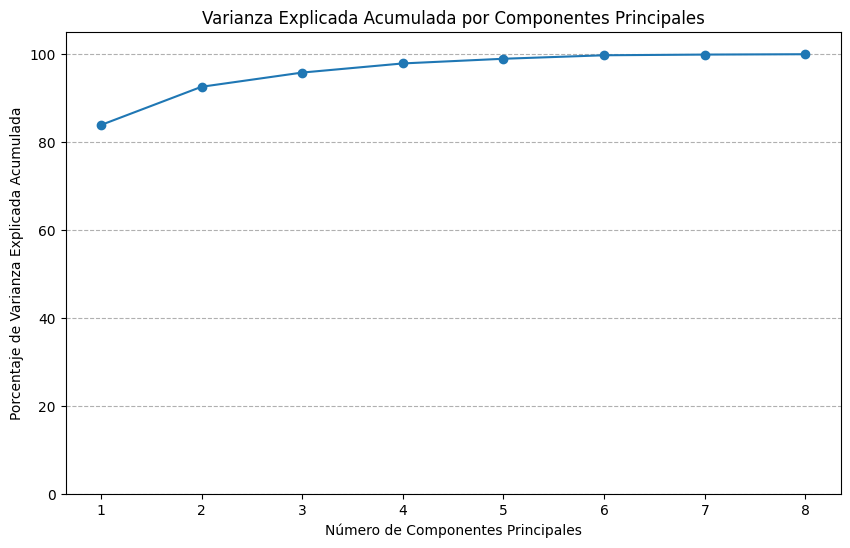

In [38]:
import matplotlib.pyplot as plt
import numpy as np

explained_variance_ratio = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio * 100)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Porcentaje de Varianza Explicada Acumulada')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.ylim(0, 105) #Es 105 para que se vea mejor el 100%, con 100 se ve feo
plt.grid(axis='y', linestyle='--')
plt.show()

## Creación del dataframe de componentes principales:

Se multiplica al dataframe estandarizado por la matriz de transformación, para obtener a los componentes principales.

In [45]:
pca = std @ transformation_matrix
df_pca = pd.DataFrame(data=pca, columns=[f'PC{i+1}' for i in range(transformation_matrix.shape[1])])

print("Componentes principales:")
print(df_pca)

Componentes principales:
           PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0    -1.322914 -1.795655 -0.789816 -0.219316  0.376985  0.196359 -0.088738   
1    -3.483651  0.092832 -0.063011  0.249972 -0.013441  0.016057 -0.007217   
2    -0.536161  0.049407  0.229275 -0.447221 -0.194706 -0.087422 -0.048665   
3    -1.458054 -0.418640  0.128083  0.006947  0.065722  0.001148 -0.184113   
4    -3.766906  0.065752 -0.235819  0.281937  0.023744  0.046232 -0.055914   
...        ...       ...       ...       ...       ...       ...       ...   
4172  0.858730 -0.187821  0.361217 -0.088223  0.208216 -0.349172 -0.068491   
4173  0.701295  0.231276 -0.289431 -0.295570  0.090923 -0.009927  0.145865   
4174  2.033016  0.693918  0.937017  0.298201  0.169654 -0.203722 -0.044843   
4175  1.601240  0.465751 -0.204418 -0.331867  0.168956 -0.051578  0.023761   
4176  4.898617  0.809736 -0.491772  0.521273  0.189564  0.580521  0.037059   

           PC8  
0     0.026437  
1   

Se puede observar una tendencia a que, entre que más grande en tamaño sea el abulón, tiende a variar más y más la edad de este, con los abulónes más pequeños teniendo edades muy similares, pero entre que el tamaño de estos va aumentando, la variabilidad en edades tambien aumenta.



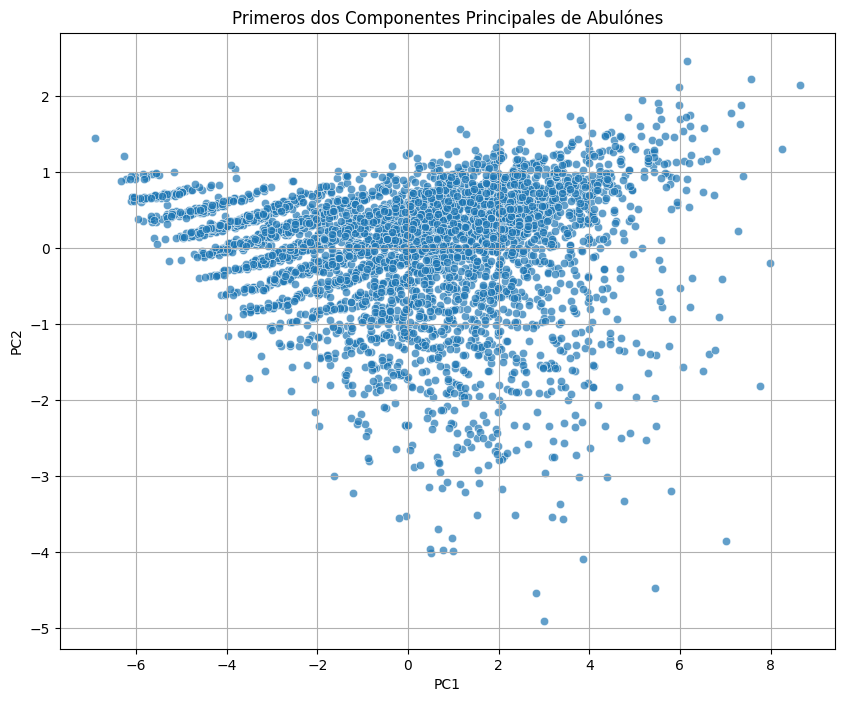

In [46]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.7)
plt.title('Primeros dos Componentes Principales de Abulónes')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

Con la adición del tercer componente principal, el cuál representa por mayor parte la altura de los abulónes, parece que la altura de los abulónes no cambia mucho dependiendo de la edad o del tamaño de estos, es decir, la mayoría de los abulónes tienen alturas muy similares, sin depender del tamaño o de la edad de este.

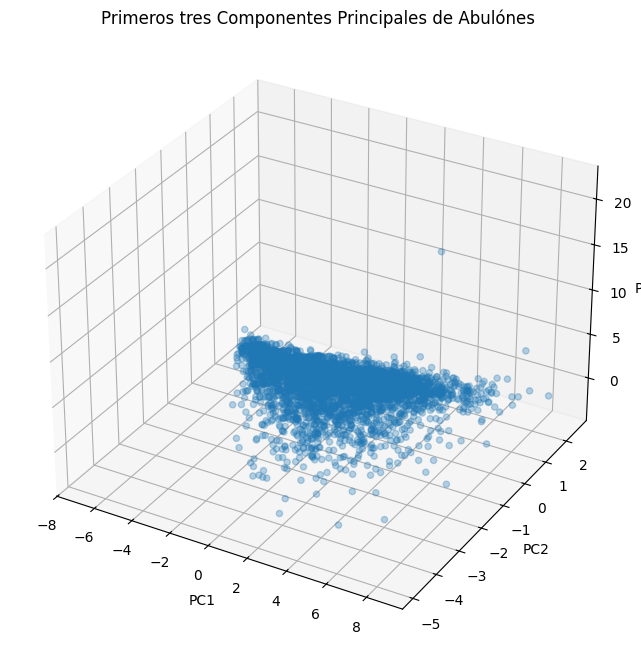

In [58]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_pca['PC1'], df_pca['PC2'], df_pca['PC3'], alpha=0.3)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Primeros tres Componentes Principales de Abulónes')
plt.show()

## Conclusiones:

El PCA fue efectivo para este dataset. Se pudieron reducir 9 dimensiones a dos principales: Una que representa el tamaño en general, y otro que tiene una correlación muy fuerte con la cantidad de anillos, y por lo tanto la edad. Esto es bastante útil ya que en el dataset los científicos querían predecir a la edad, sin necesitar contar a los anillos de manera manual

Github: https://github.com/MauriGzz555/02-Principal-Component-Analysis

# Referencias:

https://www.kaggle.com/datasets/rodolfomendes/abalone-dataset/data